In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import torch
from transformers import AutoTokenizer
from transformers.models.llama import modeling_llama
from lexplainet.heatmap import clean_tokens, pdf_heatmap, plot_text_heatmap, interactive_text_heatmap

/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [3]:
path = 'meta-llama/Llama-3.2-1B-Instruct'
model = modeling_llama.LlamaForCausalLM.from_pretrained(
    path,
    device_map='cuda',
    torch_dtype=torch.bfloat16
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(path)

# Deactivate gradients on parameters
for param in model.parameters():
    param.requires_grad = False

# Optionally enable gradient checkpointing (2x forward pass)
model.train()
model.gradient_checkpointing_enable()

In [4]:
from lexplainet.implicit.rules import dropout_rule, identity_rule, epsilon_rule
from lexplainet.implicit.core import patch_composite, undo_patch_all
from lexplainet.implicit.model_specific_patches import gated_mlp, layer_norm_forward, rms_norm_forward, patch_attention

In [8]:
undo_patch_all(model)
from transformers.models.llama import modeling_llama
patch_attention(modeling_llama)

from transformers.models.llama.modeling_llama import LlamaMLP, LlamaRMSNorm
patch_composite(model, {
    LlamaMLP: (gated_mlp, {}),
})

composite = {
            torch.nn.Linear: (epsilon_rule, {}),
            torch.nn.SiLU: (identity_rule, {}),
            LlamaRMSNorm: (rms_norm_forward, {}),
            torch.nn.Dropout: (dropout_rule, {}),
}

# undo_patch_all(model)
patch_composite(model, composite)

Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: LlamaMLP
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: SiLU
Undo patch for Layer: LlamaRMSNorm
Undo patch for Layer: LlamaRMSNorm
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: LlamaMLP
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: SiLU
Undo patch for Layer: LlamaRMSNorm
Undo patch for Layer: LlamaRMSNorm
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: LlamaMLP
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: Linear
Undo patch for Layer: SiLU
Undo patch for Layer: LlamaRMSNorm
Undo patch for Layer: LlamaRMSNorm
Undo pa

In [9]:
prompt = """Context: Mount Everest attracts many climbers, including highly experienced mountaineers.
There are two main climbing routes, one approaching the summit from the southeast in Nepal (known as the standard route)
and the other from the north in Tibet. While not posing substantial technical climbing challenges on the standard route,
Everest presents dangers such as altitude sickness, weather, and wind, as well as hazards from avalanches and the Khumbu Icefall.
As of November 2022, 310 people have died on Everest. Over 200 bodies remain on the mountain and have not been removed
due to the dangerous conditions. The first recorded efforts to reach Everest's summit were made by British mountaineers.
As Nepal did not allow foreigners to enter the country at the time, the British made several attempts on the north ridge route
from the Tibetan side. After the first reconnaissance expedition by the British in 1921 reached 7,000 m (22,970 ft) on the
North Col, the 1922 expedition pushed the north ridge route up to 8,320 m (27,300 ft), marking the first time a human had
climbed above 8,000 m (26,247 ft). The 1924 expedition resulted in one of the greatest mysteries on Everest to this day:
George Mallory and Andrew Irvine made a final summit attempt on 8 June but never returned, sparking debate as to whether
they were the first to reach the top. Tenzing Norgay and Edmund Hillary made the first documented ascent of Everest in 1953,
using the southeast ridge route. Norgay had reached 8,595 m (28,199 ft) the previous year as a member of the 1952 Swiss expedition.
The Chinese mountaineering team of Wang Fuzhou, Gonpo, and Qu Yinhua made the first reported ascent of the peak from the
north ridge on 25 May 1960.
Question: How high did they climb in 1922? According to the text, the 1922 expedition reached 8,"""
# Get input embeddings
input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).input_ids.to(model.device)
input_embeds = model.get_input_embeddings()(input_ids)

In [10]:
output_logits = model(inputs_embeds=input_embeds.requires_grad_(), use_cache=False).logits

# Take the maximum logit at last token position. You can also explain any other token, or several tokens together!
max_logits, max_indices = torch.max(output_logits[0, -1, :], dim=-1)

# Backward pass (the relevance is initialized with the value of max_logits)
max_logits.backward()

# Obtain relevance. (Works at any layer in the model!)
relevance = (input_embeds.grad * input_embeds).float().sum(-1).cpu()  # Cast to float32 for higher precision

# Normalize relevance between [-1, 1]
relevance = relevance / relevance.abs().max()

# Remove special characters that are not compatible wiht LaTeX
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens = clean_tokens(tokens)

In [11]:
relevance

tensor([[-4.4448e-02,  7.9808e-03,  5.4621e-03,  2.4123e-03,  8.1792e-03,
          9.5264e-04,  3.1968e-04,  4.3663e-03, -7.0283e-05,  2.2438e-04,
          1.2526e-03,  1.9645e-03,  1.5081e-03,  8.0342e-04,  7.8468e-04,
          1.0314e-02,  4.7153e-05,  7.7659e-04,  1.5776e-04,  1.7322e-03,
          2.6981e-03,  4.3807e-04, -2.1152e-04, -2.9829e-04, -1.4267e-04,
          1.0723e-04, -2.8981e-04,  4.2331e-04,  2.0007e-04,  6.3777e-04,
          9.7784e-05,  1.9923e-03,  2.1997e-04, -3.0298e-04,  5.3807e-04,
         -2.4695e-04, -7.2246e-04, -1.4806e-03,  2.3062e-03,  3.4065e-04,
          1.1720e-04,  3.7202e-04,  8.7293e-04,  4.1634e-04,  1.1397e-03,
          8.1888e-04,  2.7290e-03,  2.1834e-03,  1.6785e-03,  3.6042e-04,
          9.4782e-04,  9.8406e-04,  1.8687e-03,  2.4541e-03,  1.6175e-03,
          8.3209e-04,  1.5582e-04, -3.0798e-04, -5.4095e-04, -3.5061e-03,
         -1.3461e-03, -7.3938e-04,  1.6876e-03,  1.7506e-03,  8.5402e-04,
          5.1124e-04,  5.0558e-03,  1.

In [12]:
from lexplainet.heatmap.text_heatmap import pdf_heatmap, plot_text_heatmap, interactive_text_heatmap
pdf_heatmap(tokens, relevance[0].detach())

{'pdf': PosixPath('heatmap.pdf')}

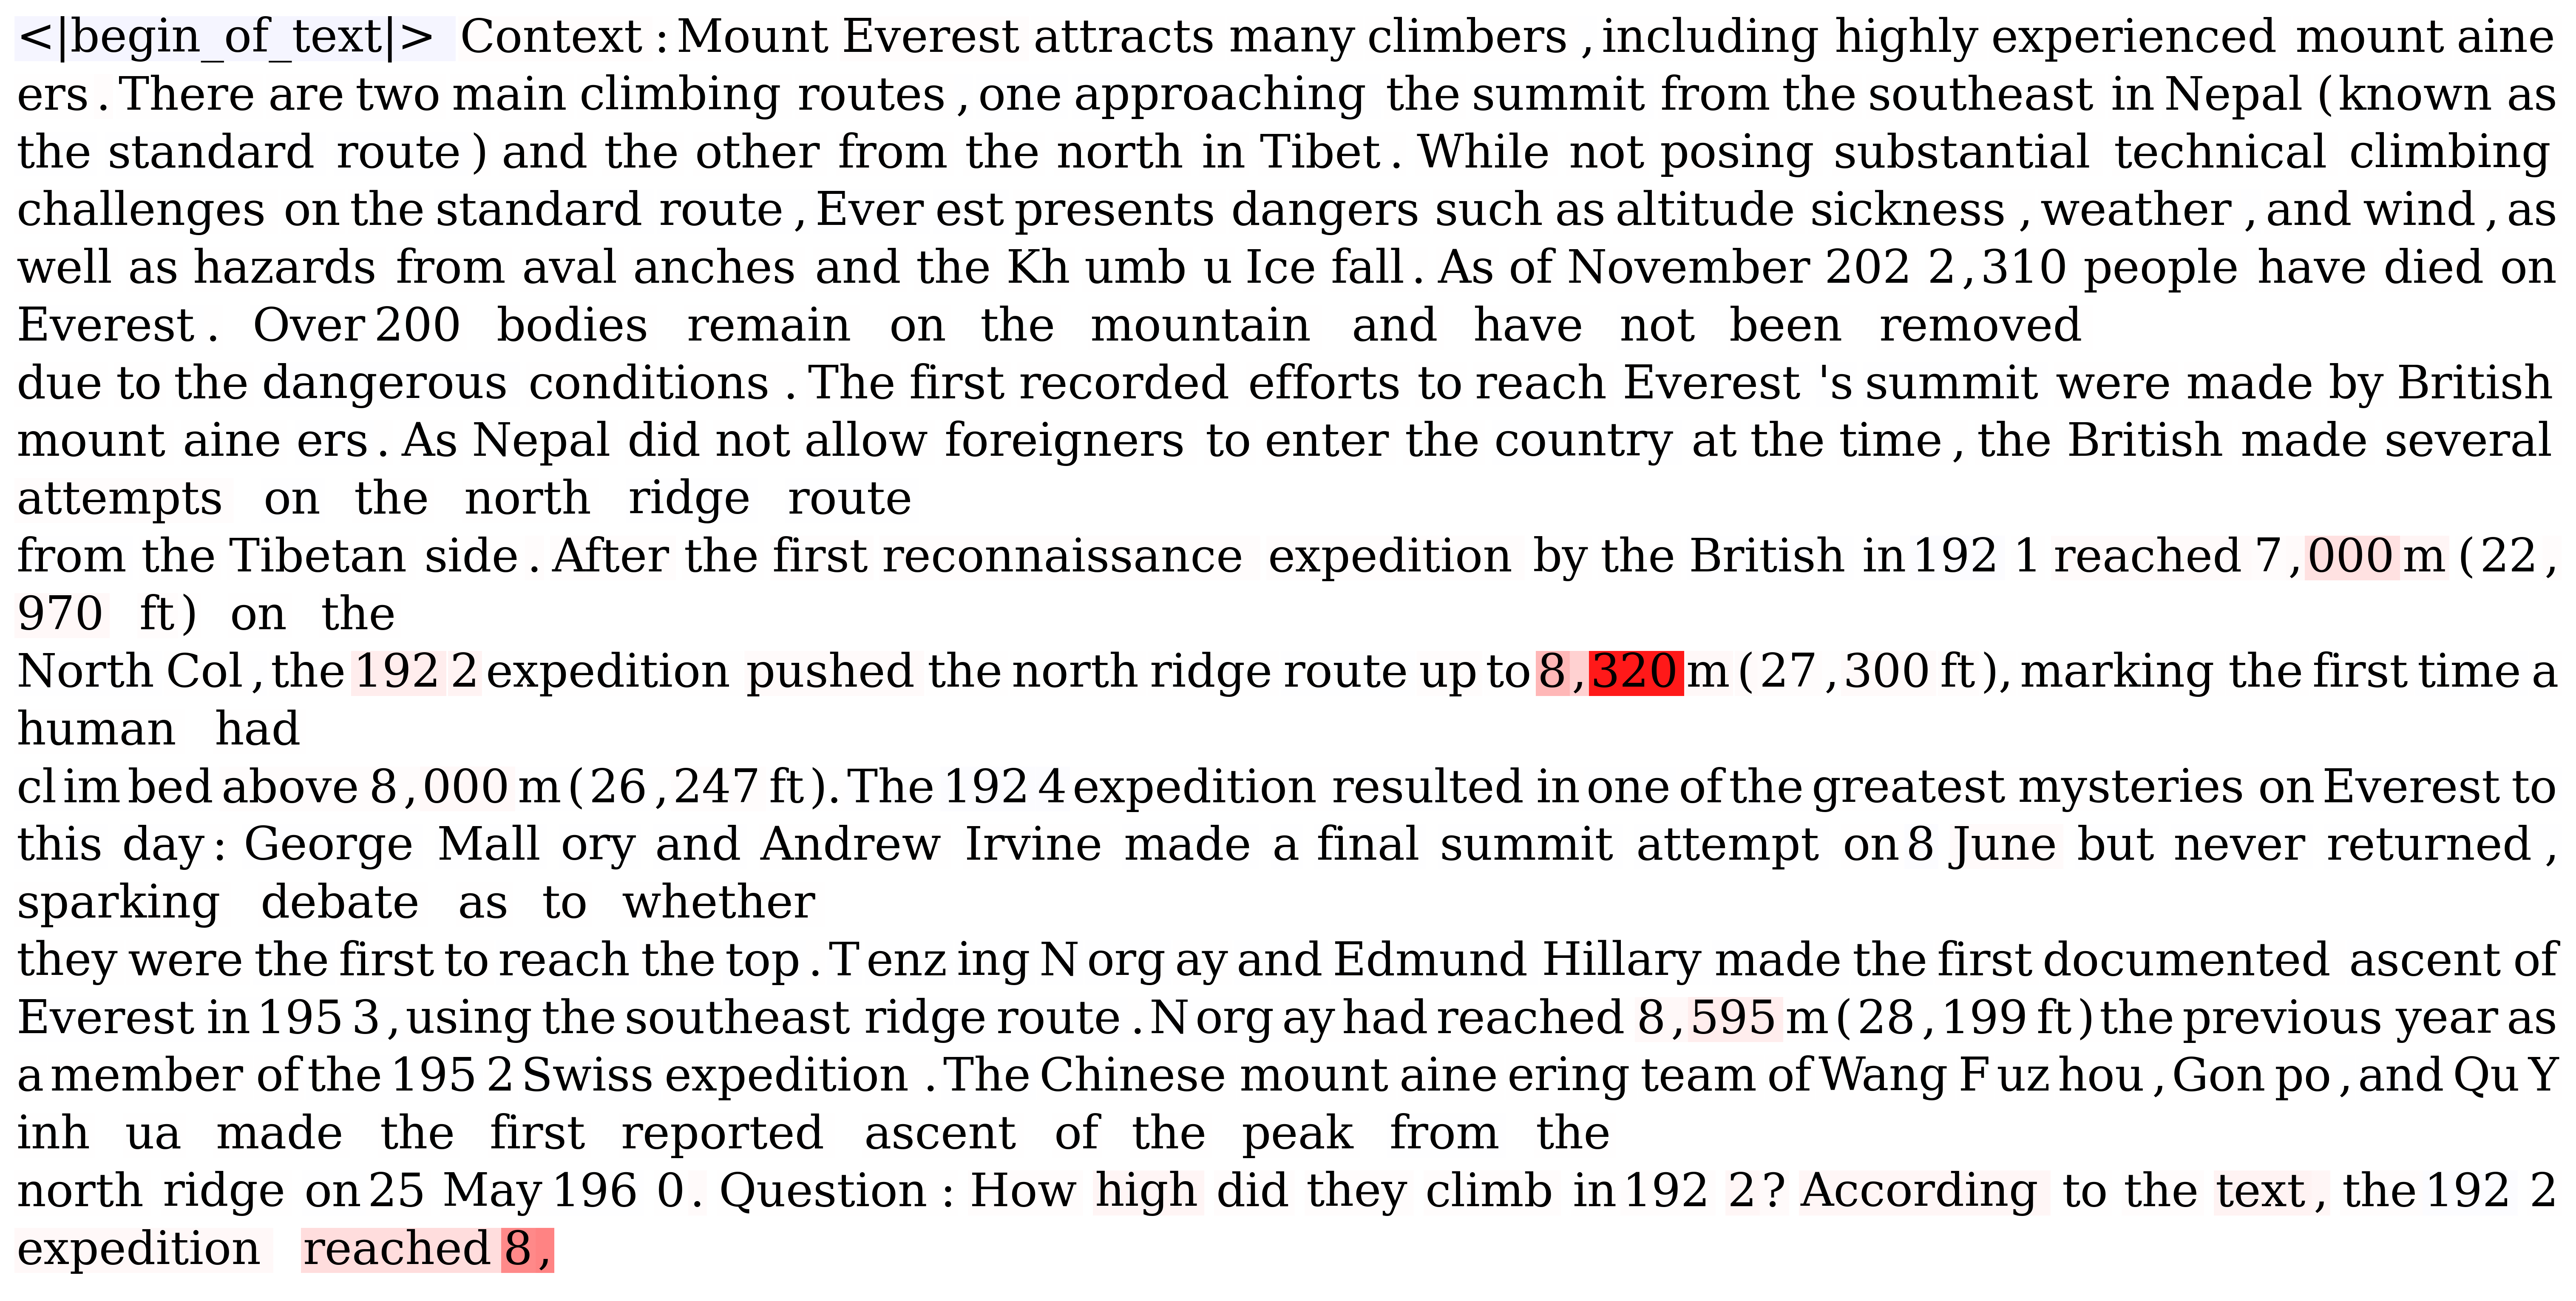

(<Figure size 6000x3000 with 1 Axes>, <Axes: >)

In [13]:
plot_text_heatmap(tokens, relevance[0].detach(), figsize=(20, 10), fontsize=26, line_height=3, dpi=300, normalize=False, )

In [14]:
interactive_text_heatmap(tokens, relevance[0].detach())